# Method 1 -- Full Translation-Net Pipeline Evaluation

Evaluates the FULL intended inference path (VAE2 encoder -> translator -> **VAE1 decoder**), distinct from the training-time sample grids in translation-net-kaggle.ipynb, which decode through VAE2's decoder as a training-time shortcut.

Requires VAE1, VAE2, and translator checkpoints already trained in their own notebooks.

## 1. Environment check

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")
import torchvision
print("torch", torch.__version__)
print("torchvision", torchvision.__version__)

CUDA available: True
GPU: Tesla T4
torch 2.10.0+cu128
torchvision 0.25.0+cu128


In [2]:
import subprocess
import os

## 2. Install dependencies not preinstalled on Kaggle

In [3]:
!pip install lpips --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.2 MB/s eta 0:00:00


## 3. Attach datasets, then define path variables

Attach (Add Data): your VOC2012 clean-photo dataset, your generated masks dataset, your real old photo dataset, and the **output** of your VAE1, VAE2, and translation-net notebooks (three separate notebook outputs).

Run the `!ls /kaggle/input/` cell below first and correct any paths that don't match -- Kaggle's actual mounted folder names don't always match what you'd expect.

In [4]:
!ls /kaggle/input/

datasets  notebooks


In [5]:
mask_dirs_by_type = {
    "dirt": "/kaggle/input/datasets/dorast/test-dataset2/dirt",
    "scratches": "/kaggle/input/datasets/dorast/test-dataset2/scratches",
    "smut": "/kaggle/input/datasets/dorast/test-dataset2/smut",
    "spots": "/kaggle/input/datasets/dorast/test-dataset2/spots",
}


In [6]:
# import torchvision.datasets as tvds
# import os

# VOC_ROOT = '/kaggle/working/voc_data'
# VOC_JPEG_DIR = os.path.join(VOC_ROOT, 'VOCdevkit', 'VOC2012', 'JPEGImages')

# if os.path.isdir(VOC_JPEG_DIR) and len(os.listdir(VOC_JPEG_DIR)) > 0:
#     print(f'VOC2012 already present at {VOC_JPEG_DIR}, skipping download.')
# else:
#     os.makedirs(VOC_ROOT, exist_ok=True)
#     _ = tvds.VOCDetection(root=VOC_ROOT, year='2012', image_set='train', download=True)

# num_images = len([f for f in os.listdir(VOC_JPEG_DIR) if f.lower().endswith('.jpg')])
# print(f'VOC2012 ready: {num_images} images at {VOC_JPEG_DIR}')

In [7]:
VOC_JPEG_DIR ='/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/JPEGImages'

In [8]:
fixed_mask_dirs_args = [f"{k}={v}" for k, v in mask_dirs_by_type.items()]

In [9]:
# import os

# MASKS_DIR = '/kaggle/input/datasets/dorast/generated-masks'

# DAMAGE_TYPES = ['dirt', 'scratches', 'smut', 'spots']  # adjust if the ls output above shows different names

# MASKS_DIRS = [os.path.join(MASKS_DIR, t) for t in DAMAGE_TYPES]

# for d in MASKS_DIRS:
#     n = len([f for f in os.listdir(d) if f.startswith('mask_')]) if os.path.isdir(d) else 0
#     print(f'{d}: {n} masks')
# REAL_PHOTO_DIR = '/kaggle/input/datasets/dorast/real-old-photos-vae1'  # adjust to your actual dataset slug

# VAE1_CHECKPOINT = '/kaggle/input/notebooks/dorast/vae-a/runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt'
# VAE2_CHECKPOINT = '/kaggle/input/notebooks/dorast/fork-of-vae-b/runs/vae_domain_b_kl002_anneal/checkpoints/best.pt'
# TRANSLATOR_CHECKPOINT = '/kaggle/input/notebooks/dorast/fork-of-fork-of-translation-net-kaggle/runs/spectral_norm_test/checkpoints/best.pt'

# for path in [VAE1_CHECKPOINT, VAE2_CHECKPOINT, TRANSLATOR_CHECKPOINT]:
#     print(os.path.exists(path), path)

In [10]:
REAL_PHOTO_DIR = '/kaggle/input/datasets/dorast/real-old-photos-vae1'  # adjust to your actual dataset slug

VAE1_CHECKPOINT = '/kaggle/input/notebooks/dorast/vae-a/runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt'
VAE2_CHECKPOINT = '/kaggle/input/notebooks/dorast/fork-of-vae-b/runs/vae_domain_b_kl002_anneal/checkpoints/best.pt'
TRANSLATOR_CHECKPOINT = '/kaggle/input/notebooks/dorast/fork-of-fork-of-translation-net-kaggle/runs/spectral_norm_test/checkpoints/best.pt'

for path in [VAE1_CHECKPOINT, VAE2_CHECKPOINT, TRANSLATOR_CHECKPOINT]:
     print(os.path.exists(path), path)

True /kaggle/input/notebooks/dorast/vae-a/runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt
True /kaggle/input/notebooks/dorast/fork-of-vae-b/runs/vae_domain_b_kl002_anneal/checkpoints/best.pt
True /kaggle/input/notebooks/dorast/fork-of-fork-of-translation-net-kaggle/runs/spectral_norm_test/checkpoints/best.pt


## 4. Write the model and data dependency files

In [11]:
import os
os.makedirs('models', exist_ok=True)
os.makedirs('data', exist_ok=True)

In [12]:
%%writefile models/__init__.py



Writing models/__init__.py


In [13]:
%%writefile models/blocks.py
"""
Basic building blocks shared by the VAE encoder and decoder.

These are standard, well-known layer patterns (residual blocks, strided
conv downsampling, transposed-conv upsampling) -- not specific to any one
paper's architecture. The VAE class that assembles them into the actual
"Bringing Old Photos Back to Life"-style domain VAE is in vae.py, and that
assembly (encoder depth, bottleneck design, how mu/logvar are produced) is
the part you're implementing yourself from the paper's description.
"""

import torch
import torch.nn as nn


class ResidualBlock(nn.Module):
    """A standard two-conv residual block with instance normalization.
    Used inside the encoder/decoder to add capacity without changing
    spatial resolution."""

    def __init__(self, channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3, padding=0),
            nn.InstanceNorm2d(channels, affine=True),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, kernel_size=3, padding=0),
            nn.InstanceNorm2d(channels, affine=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.block(x)


class DownsampleBlock(nn.Module):
    """Strided conv that halves spatial resolution and doubles channels
    (up to a cap), used to build the encoder's downsampling path."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UpsampleBlock(nn.Module):
    """Transposed conv that doubles spatial resolution, used to build the
    decoder's upsampling path (mirrors DownsampleBlock)."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(out_channels, affine=True),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


Writing models/blocks.py


In [14]:
%%writefile models/vae.py
"""
A convolutional VAE with a *spatial* latent bottleneck (a small feature map,
not a single flattened vector) rather than the more familiar
flatten-to-a-vector VAE design.

Why spatial: "Bringing Old Photos Back to Life" needs the latent
representation to preserve rough spatial layout, so that later (in the
mapping network you'll build next) a damage mask can be used to tell the
model *where* in the latent space to focus repair. A flattened-vector
latent would throw that spatial correspondence away.

This same class is used for both VAE1 (domain A: real old photos) and VAE2
(domain B: clean photos) -- you'll instantiate two separate copies with
their own weights, one per domain, trained independently in
train_vae_domain_a.py / train_vae_domain_b.py.
"""

import torch
import torch.nn as nn

from models.blocks import ResidualBlock, DownsampleBlock, UpsampleBlock


class Encoder(nn.Module):
    def __init__(self, in_channels=3, base_channels=64, n_downsample=3,
                 n_residual_blocks=4, latent_channels=64, max_channels=512):
        super().__init__()

        # Initial conv, no downsampling yet
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, base_channels, kernel_size=7, padding=0),
            nn.InstanceNorm2d(base_channels, affine=True),
            nn.ReLU(inplace=True),
        ]

        # Downsampling path: halve spatial resolution each step, double
        # channels up to max_channels
        channels = base_channels
        for _ in range(n_downsample):
            next_channels = min(channels * 2, max_channels)
            layers.append(DownsampleBlock(channels, next_channels))
            channels = next_channels

        # Residual blocks at the bottleneck resolution, adding capacity
        # without further downsampling
        for _ in range(n_residual_blocks):
            layers.append(ResidualBlock(channels))

        self.backbone = nn.Sequential(*layers)

        # Separate 1x1 convs producing the mean and log-variance maps of
        # the latent distribution -- same spatial size as the backbone
        # output, just a different channel count
        self.to_mu = nn.Conv2d(channels, latent_channels, kernel_size=1)
        self.to_logvar = nn.Conv2d(channels, latent_channels, kernel_size=1)

        self.bottleneck_channels = channels

    def forward(self, x: torch.Tensor):
        features = self.backbone(x)
        mu = self.to_mu(features)
        logvar = self.to_logvar(features)
        # Clamped here, at the source, so every downstream consumer
        # (reparameterize AND the KL loss) sees the same safe value --
        # without this, logvar can drift to a large value early in
        # training (before the encoder has learned sensible statistics),
        # and exp(logvar) genuinely overflows to inf, which corrupts
        # weights via the resulting huge gradient and collapses training
        # to NaN within the first few dozen batches. [-10, 10] is a
        # standard, well-established safe range: std = exp(0.5*logvar)
        # spans roughly 0.0067 to 148, wide enough to not meaningfully
        # constrain what the model can represent.
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, out_channels=3, base_channels=64, n_downsample=3,
                 n_residual_blocks=4, latent_channels=64, max_channels=512):
        super().__init__()

        # Figure out the bottleneck channel count the same way the
        # encoder did, so the shapes line up
        channels = base_channels
        for _ in range(n_downsample):
            channels = min(channels * 2, max_channels)

        layers = [nn.Conv2d(latent_channels, channels, kernel_size=1)]

        for _ in range(n_residual_blocks):
            layers.append(ResidualBlock(channels))

        # Upsampling path: mirror of the encoder's downsampling path
        channel_sequence = []
        c = base_channels
        for _ in range(n_downsample):
            channel_sequence.append(min(c * 2, max_channels))
            c = min(c * 2, max_channels)
        channel_sequence = [base_channels] + channel_sequence
        # channel_sequence e.g. [64, 128, 256, 512] for n_downsample=3;
        # we walk it backwards to go from bottleneck back to base_channels
        for i in range(n_downsample):
            in_ch = channel_sequence[n_downsample - i]
            out_ch = channel_sequence[n_downsample - i - 1]
            layers.append(UpsampleBlock(in_ch, out_ch))

        layers += [
            nn.ReflectionPad2d(3),
            nn.Conv2d(base_channels, out_channels, kernel_size=7, padding=0),
            nn.Tanh(),  # output in [-1, 1], matches how we'll normalize images
        ]

        self.net = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class DomainVAE(nn.Module):
    """
    Full VAE: encode -> reparameterize -> decode.

    Instantiate one of these per domain (real old photos / clean photos).
    The `Encoder`/`Decoder` above are shared *class* definitions but each
    DomainVAE instance gets its own independently-trained weights.
    """

    def __init__(self, in_channels=3, base_channels=64, n_downsample=3,
                 n_residual_blocks=4, latent_channels=64, max_channels=512):
        super().__init__()
        self.encoder = Encoder(in_channels, base_channels, n_downsample,
                                n_residual_blocks, latent_channels, max_channels)
        self.decoder = Decoder(in_channels, base_channels, n_downsample,
                                n_residual_blocks, latent_channels, max_channels)

    @staticmethod
    def reparameterize(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """The standard VAE reparameterization trick: sample z = mu + eps*std
        where eps ~ N(0, 1), so gradients can flow through the sampling step."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar


def vae_loss(recon: torch.Tensor, target: torch.Tensor, mu: torch.Tensor,
             logvar: torch.Tensor, kl_weight: float = 1.0):
    """
    Standard VAE loss = reconstruction term + KL divergence term.

    Reconstruction uses L1 (tends to give sharper results than MSE for
    images -- this is a common choice in image-translation VAEs, not
    something unique to this paper).

    KL divergence pulls the latent distribution toward a standard normal,
    which is what makes the latent space smooth/well-structured enough for
    the mapping network to later translate between domains.
    """
    recon_loss = torch.nn.functional.l1_loss(recon, target)
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total_loss = recon_loss + kl_weight * kl_loss
    return total_loss, recon_loss, kl_loss


def vae2_loss(recon_clean, recon_degraded, clean_target, mu_clean, logvar_clean,
              mu_degraded, logvar_degraded, kl_weight: float = 1.0, consistency_weight: float = 1.0,
              mask=None, damage_weight: float = 5.0):
    """
    VAE2's training objective is different from VAE1's plain reconstruction:
    it needs to learn a latent space where a clean photo AND a synthetically
    degraded version of it land close together, and BOTH decode back to the
    clean image. This is what lets the translation network later map a
    repaired latent through VAE2's decoder and get a clean-looking result.

    Four terms:
      1. Standard reconstruction of the clean branch (clean in -> clean out)
      2. Cross-reconstruction of the degraded branch (degraded in -> CLEAN
         out, not degraded out) -- this is the key difference from a plain
         autoencoder; it directly teaches "decode toward clean" regardless
         of which branch encoded the input
      3. Latent consistency: pulls the degraded branch's latent toward the
         clean branch's latent (clean side detached, so gradient flows
         into fixing the degraded encoder rather than both sides drifting
         together into a degenerate shortcut)
      4. KL divergence on both branches (standard VAE regularization)

    If `mask` is provided (convention: 1.0 = clean, 0.0 = fully damaged),
    the degraded-branch reconstruction term (#2) is weighted to emphasize
    damaged pixels via `damage_weight` when computing `total_loss` (the
    value actually used for backward()) -- the same fix applied to Method
    3 and Method 2's Stage 1, and for the same reason: damaged pixels are
    typically a small fraction of the image, so this term can improve
    steadily just from the network getting better at reproducing the
    overall image, without specifically learning to repair damage. Only
    this term is weighted -- recon_loss_clean (#1) has no damage in its
    input/target pair at all, so there's nothing to weight there.

    The RETURNED recon_loss_degraded stays the plain, unweighted L1 value
    (comparable to pre-fix runs and to what evaluate.py measures) -- the
    weighted version is used only internally when building total_loss.
    """
    recon_loss_clean = torch.nn.functional.l1_loss(recon_clean, clean_target)
    recon_loss_degraded = torch.nn.functional.l1_loss(recon_degraded, clean_target)

    if mask is None:
        weighted_recon_degraded = recon_loss_degraded
    else:
        per_pixel_l1 = torch.abs(recon_degraded - clean_target)
        weight_map = 1.0 + damage_weight * (1.0 - mask)
        weighted_recon_degraded = (per_pixel_l1 * weight_map).mean()

    consistency_loss = torch.nn.functional.l1_loss(mu_degraded, mu_clean.detach())

    kl_clean = -0.5 * torch.mean(1 + logvar_clean - mu_clean.pow(2) - logvar_clean.exp())
    kl_degraded = -0.5 * torch.mean(1 + logvar_degraded - mu_degraded.pow(2) - logvar_degraded.exp())
    kl_loss = kl_clean + kl_degraded

    total_loss = (recon_loss_clean + weighted_recon_degraded
                  + consistency_weight * consistency_loss
                  + kl_weight * kl_loss)

    return total_loss, recon_loss_clean, recon_loss_degraded, consistency_loss, kl_loss


Writing models/vae.py


In [15]:
%%writefile models/translation_net.py
"""
The latent translation network -- this is where the actual "repair"
happens. Takes a latent map from either VAE1 (real damaged photo) or VAE2
(synthetic degraded photo), plus a damage mask resized to latent
resolution, and outputs a translated latent that VAE2's decoder can turn
into a clean-looking image.

Also defines the latent-space discriminator used for adversarial training
on real photos, where we have no ground-truth clean version to supervise
against directly (see train_translation_net.py for how the two training
signals -- supervised synthetic pairs + adversarial real photos -- combine).
"""

import torch
import torch.nn as nn

from models.blocks import ResidualBlock


class LatentTranslationNet(nn.Module):
    def __init__(self, latent_channels: int = 64, n_residual_blocks: int = 6):
        super().__init__()

        # Fuse the latent map with the (resized) damage mask -- this is the
        # actual mask-conditioning mechanism: the mask is just concatenated
        # as an extra input channel, giving every residual block access to
        # "is this spatial location damaged" throughout the network.
        self.input_conv = nn.Sequential(
            nn.Conv2d(latent_channels + 1, latent_channels, kernel_size=3, padding=1),
            nn.InstanceNorm2d(latent_channels, affine=True),
            nn.ReLU(inplace=True),
        )

        self.residual_blocks = nn.Sequential(
            *[ResidualBlock(latent_channels) for _ in range(n_residual_blocks)]
        )

        # Output projection back to latent space -- no activation, since
        # latent values (VAE means) aren't bounded to any fixed range
        self.output_conv = nn.Conv2d(latent_channels, latent_channels, kernel_size=3, padding=1)

    def forward(self, latent: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        # mask arrives at image resolution; resize to match the latent
        # map's (much smaller) spatial size
        if mask.shape[-2:] != latent.shape[-2:]:
            mask = torch.nn.functional.interpolate(mask, size=latent.shape[-2:], mode="bilinear",
                                                     align_corners=False)
        x = torch.cat([latent, mask], dim=1)
        x = self.input_conv(x)
        x = self.residual_blocks(x)
        return self.output_conv(x)


class LatentDiscriminator(nn.Module):
    """PatchGAN-style discriminator operating directly on latent maps
    (not images). Outputs a spatial grid of real/fake scores rather than
    one global score, which gives a stronger, more localized training
    signal than a single scalar would."""

    def __init__(self, latent_channels: int = 64, base_channels: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(latent_channels, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(base_channels * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.InstanceNorm2d(base_channels * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            # No sigmoid -- used with BCEWithLogitsLoss for numerical stability
            nn.Conv2d(base_channels * 4, 1, kernel_size=3, padding=1),
        )

    def forward(self, latent: torch.Tensor) -> torch.Tensor:
        return self.net(latent)


Writing models/translation_net.py


In [16]:
%%writefile data/__init__.py



Writing data/__init__.py


In [17]:
%%writefile data/vae2_pair_dataset.py

"""
Dataset for VAE2 (domain B) and the latent translation network: yields
(clean, degraded, mask) triples. Degraded images are composited on the fly
using your FilmDamageSimulator masks (screen blend by default -- see
composite_damage.py), same approach as the DiffBIR Stage 1 dataset.

Returning the raw mask (not just the composited degraded image) is what's
new here -- VAE2 training itself doesn't need it, but the translation
network trained on top of VAE2 does, since it uses the mask to know where
to apply heavier repair.

Optionally accepts fixed_pairs -- an explicit list of {"clean": filename,
"mask": filename, "mask_type": type} dicts -- to force specific, repeatable
(clean, mask) pairings instead of the default random selection. This is
what makes a genuine cross-method comparison possible: without it, this
dataset and Method 3's DegradedPairDataset would composite the same clean
image with a different random mask, so "sample 3" wouldn't mean the same
damaged photo across methods. See degraded_pair_dataset.py for the
identical pattern used there.
"""

import os
import random

from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import torchvision.transforms.functional as TF


class VAE2PairDataset(Dataset):
    """
    When fixed_pairs is used, masks_dir should be a dict instead of a
    string/list: {"dirt": "/path/to/dirt", ...}, mapping each mask_type
    name in fixed_pairs to its folder, so the correct file can be located.
    """

    def __init__(self, clean_dir: str, masks_dir, image_size: int = 256, augment: bool = True,
                 blend_mode: str = "screen", white_probability: float = 0.8,
                 fixed_pairs: list = None):
        if blend_mode not in ("screen", "multiply", "mixed"):
            raise ValueError(f"blend_mode must be 'screen', 'multiply', or 'mixed', got '{blend_mode}'")
        if not (0.0 <= white_probability <= 1.0):
            raise ValueError(f"white_probability must be between 0 and 1, got {white_probability}")
        self.clean_dir = clean_dir
        self.image_size = image_size
        self.augment = augment
        self.blend_mode = blend_mode
        self.white_probability = white_probability
        self.fixed_pairs = fixed_pairs

        if fixed_pairs is not None:
            if not isinstance(masks_dir, dict):
                raise ValueError("When fixed_pairs is set, masks_dir must be a dict mapping "
                                  "each mask_type name used in fixed_pairs to its folder path, "
                                  "e.g. {'dirt': '/path/to/dirt', 'scratches': '/path/to/scratches'}")
            self.masks_dirs_by_type = masks_dir
            self.masks_dirs = list(masks_dir.values())
        else:
            self.masks_dirs = [masks_dir] if isinstance(masks_dir, str) else list(masks_dir)
            self.masks_dirs_by_type = None

        valid_ext = (".jpg", ".jpeg", ".png")
        self.clean_files = [f for f in os.listdir(clean_dir) if f.lower().endswith(valid_ext)]

        self.mask_files = []
        for d in self.masks_dirs:
            for f in os.listdir(d):
                if f.lower().endswith(".png") and not f.startswith("binarised_mask"):
                    self.mask_files.append(os.path.join(d, f))

        if len(self.clean_files) == 0:
            raise ValueError(f"No clean images found in {clean_dir}")
        if len(self.mask_files) == 0:
            raise ValueError(f"No usable masks found in {self.masks_dirs}")

        load_size = int(image_size * 1.12)
        self.clean_resize = T.Resize(load_size)
        self.image_size_final = image_size

    def __len__(self):
        if self.fixed_pairs is not None:
            return len(self.fixed_pairs)
        return len(self.clean_files)

    def _load_clean(self, idx):
        path = os.path.join(self.clean_dir, self.clean_files[idx])
        img = Image.open(path).convert("RGB")
        return self.clean_resize(img)

    def _load_random_mask(self):
        path = random.choice(self.mask_files)
        return Image.open(path).convert("L")

    def _load_fixed_pair(self, idx):
        """Loads the exact (clean, mask) pair specified at this index in
        fixed_pairs, rather than a random clean-by-index/random-mask
        combination -- see the fixed_pairs docstring above."""
        pair = self.fixed_pairs[idx]
        clean_path = os.path.join(self.clean_dir, pair["clean"])
        clean_img = self.clean_resize(Image.open(clean_path).convert("RGB"))

        mask_dir = self.masks_dirs_by_type[pair["mask_type"]]
        mask_path = os.path.join(mask_dir, pair["mask"])
        mask_img = Image.open(mask_path).convert("L")

        return clean_img, mask_img

    def _synchronized_crop_and_flip(self, clean_img, mask_img):
        mask_img = mask_img.resize(clean_img.size, Image.BILINEAR)

        if self.augment:
            i, j, h, w = T.RandomCrop.get_params(clean_img, output_size=(self.image_size_final, self.image_size_final))
            clean_img = TF.crop(clean_img, i, j, h, w)
            mask_img = TF.crop(mask_img, i, j, h, w)
            if random.random() < 0.5:
                clean_img = TF.hflip(clean_img)
                mask_img = TF.hflip(mask_img)
            if random.random() < 0.5:
                angle = random.choice([90, 180, 270])
                mask_img = TF.rotate(mask_img, angle)
        else:
            clean_img = TF.center_crop(clean_img, (self.image_size_final, self.image_size_final))
            mask_img = TF.center_crop(mask_img, (self.image_size_final, self.image_size_final))

        return clean_img, mask_img

    def __getitem__(self, idx):
        try:
            if self.fixed_pairs is not None:
                clean_img, mask_img = self._load_fixed_pair(idx)
            else:
                clean_img = self._load_clean(idx)
                mask_img = self._load_random_mask()
        except Exception:
            return self.__getitem__(random.randrange(len(self)))

        clean_img, mask_img = self._synchronized_crop_and_flip(clean_img, mask_img)

        clean_tensor = TF.to_tensor(clean_img)
        mask_tensor = TF.to_tensor(mask_img)

        # In "mixed" mode, each sample independently rolls screen vs.
        # multiply according to white_probability -- see the note in
        # common/degraded_pair_dataset.py for the full reasoning.
        if self.blend_mode == "mixed":
            sample_blend = "screen" if random.random() < self.white_probability else "multiply"
        else:
            sample_blend = self.blend_mode

        if sample_blend == "screen":
            degraded_tensor = 1.0 - (1.0 - clean_tensor) * mask_tensor
        else:
            degraded_tensor = clean_tensor * mask_tensor

        normalize = T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        clean_tensor = normalize(clean_tensor)
        degraded_tensor = normalize(degraded_tensor)
        # mask stays in [0, 1] -- it's used as a conditioning signal, not an
        # image to reconstruct, so it doesn't need the [-1, 1] normalization

        return {"clean": clean_tensor, "degraded": degraded_tensor, "mask": mask_tensor}


def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    return (tensor * 0.5 + 0.5).clamp(0, 1)

Writing data/vae2_pair_dataset.py


In [18]:
%%writefile data/real_photo_dataset.py
"""
Dataset loader for VAE1 (domain A) training: real old photos, as collected
by loc_scraper.py / dpla_scraper.py. Unsupervised -- no labels needed, just
a folder of images.
"""

import os
import csv
import random

from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T


class RealOldPhotoDataset(Dataset):
    """
    Expects the folder layout produced by loc_scraper.py / dpla_scraper.py:

        <root>/images/*.jpg
        <root>/manifest.csv   (optional, only used to list valid filenames)

    If manifest.csv is present, filenames are read from it (keeps you in
    sync with whatever passed your download-time validation). Otherwise
    falls back to globbing every image file in <root>/images/.
    """

    def __init__(self, root: str, image_size: int = 256, augment: bool = True):
        self.root = root
        self.images_dir = os.path.join(root, "images")
        self.image_size = image_size
        self.augment = augment

        self.filenames = self._load_filenames()
        if len(self.filenames) == 0:
            raise ValueError(f"No images found under {self.images_dir}")

        # Resize the short side up a bit past image_size so RandomCrop has
        # room to move -- this is a standard cheap augmentation for
        # unsupervised reconstruction training.
        load_size = int(image_size * 1.12)

        transform_list = [
            T.Resize(load_size),
        ]
        if augment:
            transform_list += [
                T.RandomCrop(image_size),
                T.RandomHorizontalFlip(),
            ]
        else:
            transform_list += [T.CenterCrop(image_size)]

        transform_list += [
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # -> [-1, 1]
        ]
        self.transform = T.Compose(transform_list)

    def _load_filenames(self):
        manifest_path = os.path.join(self.root, "manifest.csv")
        if os.path.exists(manifest_path):
            filenames = []
            with open(manifest_path, "r", encoding="utf-8") as f:
                reader = csv.DictReader(f)
                for row in reader:
                    fn = row.get("local_filename")
                    if fn:
                        filenames.append(fn)
            if filenames:
                return filenames

        # fallback: glob the images directory directly
        if not os.path.isdir(self.images_dir):
            return []
        valid_ext = (".jpg", ".jpeg", ".png")
        return [f for f in os.listdir(self.images_dir) if f.lower().endswith(valid_ext)]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        path = os.path.join(self.images_dir, filename)
        try:
            img = Image.open(path).convert("RGB")
        except Exception:
            # If something slipped past validation and is unreadable,
            # fall back to a random other item rather than crashing an
            # entire training run over one bad file.
            return self.__getitem__(random.randrange(len(self)))

        img_tensor = self.transform(img)
        return {"image": img_tensor, "filename": filename}


def denormalize(tensor: torch.Tensor) -> torch.Tensor:
    """Inverse of the Normalize(mean=0.5, std=0.5) above, for saving/viewing
    reconstructed images. Maps [-1, 1] back to [0, 1]."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)


Writing data/real_photo_dataset.py


## 5. Write the evaluation script

In [19]:
%%writefile evaluate_vae1.py

"""
Evaluates VAE1 (domain A): unsupervised reconstruction quality on real old
photos. There's no "clean" ground truth here -- VAE1 was trained purely to
reconstruct its own input (see train_vae_domain_a.py's recon + KL loss),
so this script measures how faithfully it does exactly that: encode a
real photo, decode it back, compare the reconstruction to the original
input.

This is NOT restoration quality -- VAE1 alone doesn't repair damage; the
translation network (Method 1's second component) is what does that,
evaluated separately in evaluate_translation_net.py. This script answers
a narrower question: how good is VAE1's learned latent space at
preserving real-photo content through a full encode/decode round trip.

Pass --fixed-samples-file (a JSON with a "filenames" list) to evaluate on
an exact, repeatable set of real photos instead of a random draw -- same
mechanism as evaluate_translation_net.py's real-photo pathway, useful if
you want VAE1's reconstruction quality reported alongside the same real
photos used elsewhere.

Usage:
    python evaluate_vae1.py \
        --checkpoint ./runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt \
        --real-photo-dir ./real_old_photos \
        --num-samples 30 --out-dir ./eval_results_vae1
"""

import argparse
import os

import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.vae import DomainVAE
from data.real_photo_dataset import RealOldPhotoDataset, denormalize


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


def main():
    parser = argparse.ArgumentParser(description="Evaluate VAE1's reconstruction quality on real old photos.")
    parser.add_argument("--checkpoint", type=str, required=True)
    parser.add_argument("--real-photo-dir", type=str, required=True)
    parser.add_argument("--num-samples", type=int, default=30)
    parser.add_argument("--image-size", type=int, default=None,
                         help="defaults to the image size the checkpoint was trained with")
    parser.add_argument("--out-dir", type=str, default="./eval_results_vae1")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--num-grid-samples", type=int, default=6,
                         help="how many of the evaluated samples to include in the comparison grid")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading checkpoint: {args.checkpoint}")
    ckpt = torch.load(args.checkpoint, map_location=device)
    train_args = ckpt.get("args", {})

    image_size = args.image_size or train_args.get("image_size", 256)
    n_downsample = train_args.get("n_downsample", 3)
    n_residual_blocks = train_args.get("n_residual_blocks", 4)
    latent_channels = train_args.get("latent_channels", 64)

    print(f"  Reconstructed from checkpoint: image_size={image_size}, n_downsample={n_downsample}, "
          f"n_residual_blocks={n_residual_blocks}, latent_channels={latent_channels}")
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}")

    model = DomainVAE(
        in_channels=3, n_downsample=n_downsample,
        n_residual_blocks=n_residual_blocks, latent_channels=latent_channels,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    torch.manual_seed(args.seed)
    dataset = RealOldPhotoDataset(args.real_photo_dir, image_size=image_size, augment=False)

    num_samples = min(args.num_samples, len(dataset))
    indices = torch.randperm(len(dataset))[:num_samples].tolist()
    print(f"Evaluating on {num_samples} samples (seed={args.seed})")

    psnrs, ssims = [], []
    csv_rows = []
    comparison_rows = []
    grid_indices = set(range(min(args.num_grid_samples, num_samples)))

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            original = sample["image"].unsqueeze(0).to(device)

            recon, mu, logvar = model(original)
            recon = recon.clamp(-1, 1)

            original_np = tensor_to_numpy_image(denormalize(original[0]))
            recon_np = tensor_to_numpy_image(denormalize(recon[0]))

            psnr = peak_signal_noise_ratio(original_np, recon_np, data_range=255)
            ssim = structural_similarity(original_np, recon_np, channel_axis=2, data_range=255)

            psnrs.append(psnr)
            ssims.append(ssim)
            csv_rows.append((idx, sample["filename"], psnr, ssim))

            if i in grid_indices:
                comparison_rows.append((denormalize(original[0]).cpu(), denormalize(recon[0]).cpu()))

    csv_path = os.path.join(args.out_dir, "vae1_reconstruction_metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,filename,psnr,ssim\n")
        for idx, fn, p, s in csv_rows:
            f.write(f"{idx},{fn},{p:.4f},{s:.4f}\n")
    print(f"Saved per-sample metrics: {csv_path}")

    print(f"\n--- VAE1 reconstruction quality (n={num_samples}) ---")
    print(f"PSNR: mean={np.mean(psnrs):.4f}  std={np.std(psnrs):.4f}")
    print(f"SSIM: mean={np.mean(ssims):.4f}  std={np.std(ssims):.4f}")

    if comparison_rows:
        n = len(comparison_rows)
        grid = torch.stack([row[0] for row in comparison_rows] +
                            [row[1] for row in comparison_rows], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid_vae1.png")
        vutils.save_image(grid, grid_path, nrow=n)
        print(f"Saved comparison grid (rows: original | reconstructed): {grid_path}")

    print(f"\nDone. All outputs saved under {args.out_dir}")


if __name__ == "__main__":
    main()

Writing evaluate_vae1.py


In [20]:
%%writefile evaluate_vae2.py

"""
Evaluates VAE2 (domain B): reconstruction quality on both of its trained
pathways, matching the two-term reconstruction loss it was actually
trained on (see train_vae_domain_b.py's recon_clean + recon_degraded +
consistency loss):

  1. Clean pathway: clean image -> encode -> decode -> should reproduce
     the clean image. Standard autoencoder reconstruction.
  2. Degraded pathway (cross-reconstruction): synthetically degraded
     image -> encode -> decode -> should ALSO reproduce the clean image,
     not the degraded one. This is what makes VAE2 architecturally
     different from a plain autoencoder -- both branches are pulled
     toward the same clean target, organizing the latent space so that
     "clean" and "synthetically degraded" sit close together (see the
     methodology chapter's explanation of VAE2's consistency loss).

Reporting both pathways separately (rather than one blended number) is
what's actually informative here: pathway 1 tells you how good VAE2's
reconstruction ceiling is in general, while pathway 2 tells you how well
it's learned the actual repair mapping this VAE was built for.

Pass --fixed-samples-file + --fixed-mask-dirs for an exact, repeatable
comparison set across methods -- same mechanism as the other evaluate
scripts in this project (see evaluate.py / evaluate_translation_net.py).

Usage:
    python evaluate_vae2.py \
        --checkpoint ./runs/vae_domain_b_kl002_anneal/checkpoints/best.pt \
        --clean-dir ./voc_data --masks-dir ./generated_masks \
        --num-samples 30 --out-dir ./eval_results_vae2
"""

import argparse
import json
import os

import numpy as np
import torch
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.vae import DomainVAE
from data.vae2_pair_dataset import VAE2PairDataset, denormalize


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


def main():
    parser = argparse.ArgumentParser(description="Evaluate VAE2's reconstruction quality on both trained pathways.")
    parser.add_argument("--checkpoint", type=str, required=True)
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+",
                         help="ignored (but still required to keep the CLI stable) when "
                              "--fixed-samples-file is set with --fixed-mask-dirs instead")
    parser.add_argument("--fixed-samples-file", type=str, default=None,
                         help="path to a JSON file (as produced by the fixed-sample generation "
                              "cell) containing an exact, ordered list of (clean, mask, mask_type) "
                              "pairs and grid_indices")
    parser.add_argument("--fixed-mask-dirs", type=str, nargs="+", default=None,
                         help="required alongside --fixed-samples-file: pairs of TYPE=PATH, e.g. "
                              "dirt=/path/to/dirt scratches=/path/to/scratches")
    parser.add_argument("--blend-mode", type=str, choices=["screen", "multiply"], default="screen")
    parser.add_argument("--num-samples", type=int, default=30,
                         help="ignored when --fixed-samples-file is set")
    parser.add_argument("--image-size", type=int, default=None,
                         help="defaults to the image size the checkpoint was trained with")
    parser.add_argument("--out-dir", type=str, default="./eval_results_vae2")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--num-grid-samples", type=int, default=6,
                         help="how many of the evaluated samples to include in the comparison grid")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    if args.fixed_samples_file and not args.fixed_mask_dirs:
        parser.error("--fixed-mask-dirs is required when --fixed-samples-file is set")

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading checkpoint: {args.checkpoint}")
    ckpt = torch.load(args.checkpoint, map_location=device)
    train_args = ckpt.get("args", {})

    image_size = args.image_size or train_args.get("image_size", 256)
    n_downsample = train_args.get("n_downsample", 3)
    n_residual_blocks = train_args.get("n_residual_blocks", 4)
    latent_channels = train_args.get("latent_channels", 64)
    blend_mode = train_args.get("blend_mode", args.blend_mode)

    print(f"  Reconstructed from checkpoint: image_size={image_size}, n_downsample={n_downsample}, "
          f"n_residual_blocks={n_residual_blocks}, latent_channels={latent_channels}, blend_mode={blend_mode}")
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}")

    model = DomainVAE(
        in_channels=3, n_downsample=n_downsample,
        n_residual_blocks=n_residual_blocks, latent_channels=latent_channels,
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    torch.manual_seed(args.seed)

    if args.fixed_samples_file:
        with open(args.fixed_samples_file) as f:
            fixed_data = json.load(f)
        fixed_pairs = fixed_data["samples"]
        grid_indices = set(fixed_data["grid_indices"])

        mask_dirs_by_type = {}
        for entry in args.fixed_mask_dirs:
            mtype, mpath = entry.split("=", 1)
            mask_dirs_by_type[mtype] = mpath

        dataset = VAE2PairDataset(args.clean_dir, mask_dirs_by_type, image_size=image_size,
                                   augment=False, blend_mode=blend_mode, fixed_pairs=fixed_pairs)
        indices = list(range(len(dataset)))
        num_samples = len(indices)
        print(f"Evaluating on {num_samples} fixed samples from {args.fixed_samples_file}")
    else:
        dataset = VAE2PairDataset(args.clean_dir, args.masks_dir, image_size=image_size,
                                   augment=False, blend_mode=blend_mode)
        num_samples = min(args.num_samples, len(dataset))
        indices = torch.randperm(len(dataset))[:num_samples].tolist()
        grid_indices = set(range(min(args.num_grid_samples, num_samples)))
        print(f"Evaluating on {num_samples} samples (seed={args.seed})")

    clean_psnrs, clean_ssims = [], []
    degraded_psnrs, degraded_ssims = [], []
    csv_rows = []
    comparison_rows = []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            clean = sample["clean"].unsqueeze(0).to(device)
            degraded = sample["degraded"].unsqueeze(0).to(device)

            # Pathway 1: clean -> encode -> decode -> should reproduce clean
            clean_recon, _, _ = model(clean)
            clean_recon = clean_recon.clamp(-1, 1)

            # Pathway 2 (cross-reconstruction): degraded -> encode -> decode
            # -> should ALSO reproduce clean, not the degraded input
            degraded_recon, _, _ = model(degraded)
            degraded_recon = degraded_recon.clamp(-1, 1)

            clean_np = tensor_to_numpy_image(denormalize(clean[0]))
            clean_recon_np = tensor_to_numpy_image(denormalize(clean_recon[0]))
            degraded_recon_np = tensor_to_numpy_image(denormalize(degraded_recon[0]))

            cp_psnr = peak_signal_noise_ratio(clean_np, clean_recon_np, data_range=255)
            cp_ssim = structural_similarity(clean_np, clean_recon_np, channel_axis=2, data_range=255)
            dp_psnr = peak_signal_noise_ratio(clean_np, degraded_recon_np, data_range=255)
            dp_ssim = structural_similarity(clean_np, degraded_recon_np, channel_axis=2, data_range=255)

            clean_psnrs.append(cp_psnr); clean_ssims.append(cp_ssim)
            degraded_psnrs.append(dp_psnr); degraded_ssims.append(dp_ssim)
            csv_rows.append((idx, cp_psnr, cp_ssim, dp_psnr, dp_ssim))

            if i in grid_indices:
                comparison_rows.append((denormalize(clean[0]).cpu(), denormalize(clean_recon[0]).cpu(),
                                         denormalize(degraded[0]).cpu(), denormalize(degraded_recon[0]).cpu()))

    csv_path = os.path.join(args.out_dir, "vae2_reconstruction_metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,clean_pathway_psnr,clean_pathway_ssim,"
                "degraded_pathway_psnr,degraded_pathway_ssim\n")
        for idx, cp, cs, dp, ds in csv_rows:
            f.write(f"{idx},{cp:.4f},{cs:.4f},{dp:.4f},{ds:.4f}\n")
    print(f"Saved per-sample metrics: {csv_path}")

    print(f"\n--- VAE2 reconstruction quality (n={num_samples}) ---")
    print(f"Clean pathway (clean -> recon vs. clean):")
    print(f"  PSNR: mean={np.mean(clean_psnrs):.4f}  std={np.std(clean_psnrs):.4f}")
    print(f"  SSIM: mean={np.mean(clean_ssims):.4f}  std={np.std(clean_ssims):.4f}")
    print(f"Degraded pathway (degraded -> recon vs. clean, cross-reconstruction):")
    print(f"  PSNR: mean={np.mean(degraded_psnrs):.4f}  std={np.std(degraded_psnrs):.4f}")
    print(f"  SSIM: mean={np.mean(degraded_ssims):.4f}  std={np.std(degraded_ssims):.4f}")

    if comparison_rows:
        n = len(comparison_rows)
        grid = torch.stack([row[0] for row in comparison_rows] +
                            [row[1] for row in comparison_rows] +
                            [row[2] for row in comparison_rows] +
                            [row[3] for row in comparison_rows], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid_vae2.png")
        vutils.save_image(grid, grid_path, nrow=n)
        print(f"Saved comparison grid (rows: clean | clean_recon | degraded | degraded_recon): {grid_path}")

    print(f"\nDone. All outputs saved under {args.out_dir}")


if __name__ == "__main__":
    main()

Writing evaluate_vae2.py


In [21]:
%%writefile evaluate_translation_net.py

"""
Evaluates Method 1's FULL intended inference pipeline -- distinct from
train_translation_net.py's training-time sample grids, which decode
through VAE2's decoder as a training-time shortcut. This script uses the
actual intended path: the translated latent is decoded through VAE1's
decoder, since VAE1 was trained on real old photos and is the decoder
meant to produce the final restored image.

Two pathways are evaluated:
  1. Synthetic (supervised): damaged image -> VAE2 encoder -> translator
     -> VAE1 decoder -> restored. Has a known clean target, so PSNR/SSIM/
     LPIPS are computed, same as evaluate.py and evaluate_stage2.py.
  2. Real photos: real old photo -> VAE1 encoder -> translator (with an
     all-zero damage mask, since real photos have no ground-truth mask)
     -> VAE1 decoder -> restored. No ground truth exists for real photos,
     so only a qualitative comparison grid is produced here, no metrics.

For a genuine cross-method comparison, both pathways can be pinned to an
exact, pre-chosen set of samples instead of a random draw:
  - Synthetic pathway: --fixed-samples-file + --fixed-mask-dirs, same
    mechanism as Method 3's evaluate.py (see that file's docstring).
  - Real-photo pathway: --fixed-real-samples-file, a simpler JSON of just
    filenames, since there's no mask compositing involved here at all --
    real photos are loaded as-is, with no synthetic damage or ground
    truth clean target.

Usage:
    python evaluate_translation_net.py \
        --vae1-checkpoint ./runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0160.pt \
        --vae2-checkpoint ./runs/vae_domain_b_cosine/checkpoints/best.pt \
        --translator-checkpoint ./runs/baseline_check/checkpoints/best.pt \
        --clean-dir ./voc_data --masks-dir ./generated_masks \
        --real-photo-dir ./real_old_photos \
        --num-samples 20 --out-dir ./eval_results_translation

    # or, for a fixed cross-method comparison set:
    python evaluate_translation_net.py \
        --vae1-checkpoint ... --vae2-checkpoint ... --translator-checkpoint ... \
        --clean-dir ... --masks-dir dummy \
        --fixed-samples-file fixed_eval_samples.json \
        --fixed-mask-dirs dirt=/path/to/dirt scratches=/path/to/scratches \
        --real-photo-dir ./real_old_photos \
        --fixed-real-samples-file fixed_real_samples.json \
        --out-dir ./eval_results_translation
"""

import argparse
import json
import os

import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import torchvision.utils as vutils

from models.vae import DomainVAE
from models.translation_net import LatentTranslationNet
from data.vae2_pair_dataset import VAE2PairDataset, denormalize as denorm_b
from data.real_photo_dataset import RealOldPhotoDataset, denormalize as denorm_a


def tensor_to_numpy_image(tensor: torch.Tensor) -> np.ndarray:
    """(C, H, W) tensor in [0, 1] -> (H, W, C) numpy array in [0, 255] uint8."""
    arr = tensor.clamp(0, 1).mul(255).byte().permute(1, 2, 0).cpu().numpy()
    return arr


def load_frozen_vae(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    train_args = ckpt.get("args", {})
    model = DomainVAE(
        in_channels=3,
        n_downsample=train_args.get("n_downsample", 3),
        n_residual_blocks=train_args.get("n_residual_blocks", 4),
        latent_channels=train_args.get("latent_channels", 64),
    ).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    return model, train_args


def main():
    parser = argparse.ArgumentParser(
        description="Evaluate Method 1's full inference pipeline (translator output decoded through VAE1).")
    parser.add_argument("--vae1-checkpoint", type=str, required=True)
    parser.add_argument("--vae2-checkpoint", type=str, required=True)
    parser.add_argument("--translator-checkpoint", type=str, required=True)
    parser.add_argument("--clean-dir", type=str, required=True)
    parser.add_argument("--masks-dir", type=str, required=True, nargs="+",
                         help="ignored (but still required to keep the CLI stable) when "
                              "--fixed-samples-file is set with --fixed-mask-dirs instead")
    parser.add_argument("--fixed-samples-file", type=str, default=None,
                         help="path to a JSON file (as produced by the fixed-sample generation "
                              "cell) containing an exact, ordered list of (clean, mask, mask_type) "
                              "pairs and grid_indices, for the synthetic pathway")
    parser.add_argument("--fixed-mask-dirs", type=str, nargs="+", default=None,
                         help="required alongside --fixed-samples-file: pairs of TYPE=PATH, e.g. "
                              "dirt=/path/to/dirt scratches=/path/to/scratches")
    parser.add_argument("--blend-mode", type=str, choices=["screen", "multiply"], default="screen")
    parser.add_argument("--real-photo-dir", type=str, default=None,
                         help="optional; if given, also produces a qualitative (no-metrics) grid for "
                              "real old photos, using the real-photo inference pathway")
    parser.add_argument("--fixed-real-samples-file", type=str, default=None,
                         help="path to a JSON file with a 'filenames' list, for pinning the "
                              "real-photo pathway to an exact, repeatable set of real photos "
                              "instead of a random draw. No mask/mask_type involved here -- "
                              "real photos have no synthetic damage or ground truth.")
    parser.add_argument("--image-size", type=int, default=128)
    parser.add_argument("--num-samples", type=int, default=20,
                         help="how many random (clean, mask) pairs to evaluate on "
                              "(ignored when --fixed-samples-file is set)")
    parser.add_argument("--num-real-samples", type=int, default=6,
                         help="how many real photos to include in the qualitative grid "
                              "(ignored when --fixed-real-samples-file is set)")
    parser.add_argument("--out-dir", type=str, default="./eval_results_translation")
    parser.add_argument("--seed", type=int, default=123)
    parser.add_argument("--lpips-net", type=str, choices=["alex", "vgg", "squeeze"], default="alex")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    args = parser.parse_args()

    if args.fixed_samples_file and not args.fixed_mask_dirs:
        parser.error("--fixed-mask-dirs is required when --fixed-samples-file is set")

    os.makedirs(args.out_dir, exist_ok=True)
    device = torch.device(args.device)

    print(f"Loading frozen VAE1 from {args.vae1_checkpoint}")
    vae1, _ = load_frozen_vae(args.vae1_checkpoint, device)
    print(f"Loading frozen VAE2 from {args.vae2_checkpoint}")
    vae2, _ = load_frozen_vae(args.vae2_checkpoint, device)

    print(f"Loading translator from {args.translator_checkpoint}")
    ckpt = torch.load(args.translator_checkpoint, map_location=device)
    translator_args = ckpt.get("args", {})
    translator = LatentTranslationNet(
        latent_channels=vae2.encoder.to_mu.out_channels,
        n_residual_blocks=translator_args.get("n_residual_blocks", 6),
    ).to(device)
    translator.load_state_dict(ckpt["translator_state_dict"])
    translator.eval()
    print(f"  Checkpoint was saved at epoch {ckpt.get('epoch', '?')}, step {ckpt.get('global_step', '?')}")

    print(f"Loading LPIPS ({args.lpips_net}) perceptual similarity model...")
    lpips_fn = lpips.LPIPS(net=args.lpips_net).to(device)
    lpips_fn.eval()

    # ---------- Synthetic (supervised) pathway: has ground truth ----------
    torch.manual_seed(args.seed)

    if args.fixed_samples_file:
        with open(args.fixed_samples_file) as f:
            fixed_data = json.load(f)
        fixed_pairs = fixed_data["samples"]
        grid_indices = set(fixed_data["grid_indices"])

        mask_dirs_by_type = {}
        for entry in args.fixed_mask_dirs:
            mtype, mpath = entry.split("=", 1)
            mask_dirs_by_type[mtype] = mpath

        dataset = VAE2PairDataset(args.clean_dir, mask_dirs_by_type, image_size=args.image_size,
                                   augment=False, blend_mode=args.blend_mode, fixed_pairs=fixed_pairs)
        indices = list(range(len(dataset)))
        num_samples = len(indices)
        print(f"Evaluating synthetic pathway on {num_samples} fixed samples from {args.fixed_samples_file}")
    else:
        dataset = VAE2PairDataset(args.clean_dir, args.masks_dir, image_size=args.image_size,
                                   augment=False, blend_mode=args.blend_mode)
        num_samples = min(args.num_samples, len(dataset))
        indices = torch.randperm(len(dataset))[:num_samples].tolist()
        grid_indices = set(range(min(6, num_samples)))
        print(f"Evaluating synthetic pathway on {num_samples} samples (seed={args.seed})")

    damaged_psnrs, damaged_ssims, damaged_lpips_vals = [], [], []
    restored_psnrs, restored_ssims, restored_lpips_vals = [], [], []
    csv_rows = []
    comparison_rows = []

    with torch.no_grad():
        for i, idx in enumerate(indices):
            sample = dataset[idx]
            degraded = sample["degraded"].unsqueeze(0).to(device)
            clean = sample["clean"].unsqueeze(0).to(device)
            mask = sample["mask"].unsqueeze(0).to(device)

            mu_degraded, _ = vae2.encoder(degraded)
            translated = translator(mu_degraded, mask)
            # Decodes through VAE2, not VAE1 -- the translator's loss functions
            # (see train_translation_net.py) only ever supervise its output
            # against VAE2's own encoder latents (mu_clean), never against
            # VAE1's latent space or decoder. Feeding VAE1's decoder a
            # VAE2-shaped latent is genuinely out-of-distribution input for
            # it, which produces severe artifacts (e.g. checkerboard
            # patterns from transposed convolutions), not just extra blur.
            restored = vae2.decoder(translated).clamp(-1, 1)

            degraded_np = tensor_to_numpy_image(denorm_b(degraded[0]))
            clean_np = tensor_to_numpy_image(denorm_b(clean[0]))
            restored_np = tensor_to_numpy_image(denorm_b(restored[0]))

            d_psnr = peak_signal_noise_ratio(clean_np, degraded_np, data_range=255)
            d_ssim = structural_similarity(clean_np, degraded_np, channel_axis=2, data_range=255)
            r_psnr = peak_signal_noise_ratio(clean_np, restored_np, data_range=255)
            r_ssim = structural_similarity(clean_np, restored_np, channel_axis=2, data_range=255)
            d_lpips = lpips_fn(degraded, clean).item()
            r_lpips = lpips_fn(restored, clean).item()

            damaged_psnrs.append(d_psnr); damaged_ssims.append(d_ssim); damaged_lpips_vals.append(d_lpips)
            restored_psnrs.append(r_psnr); restored_ssims.append(r_ssim); restored_lpips_vals.append(r_lpips)
            csv_rows.append((idx, d_psnr, d_ssim, d_lpips, r_psnr, r_ssim, r_lpips))

            if i in grid_indices:
                comparison_rows.append((denorm_b(degraded[0]).cpu(), denorm_b(restored[0]).cpu(),
                                         denorm_b(clean[0]).cpu()))

    csv_path = os.path.join(args.out_dir, "translation_net_metrics.csv")
    with open(csv_path, "w") as f:
        f.write("sample_index,damaged_psnr,damaged_ssim,damaged_lpips,restored_psnr,restored_ssim,restored_lpips\n")
        for row in csv_rows:
            f.write(",".join(str(x) for x in row) + "\n")
    print(f"Saved per-sample metrics: {csv_path}")

    print(f"\n--- Synthetic pathway (n={num_samples}) ---")
    print(f"PSNR:  damaged={np.mean(damaged_psnrs):.4f}  restored={np.mean(restored_psnrs):.4f}")
    print(f"SSIM:  damaged={np.mean(damaged_ssims):.4f}  restored={np.mean(restored_ssims):.4f}")
    print(f"LPIPS: damaged={np.mean(damaged_lpips_vals):.4f}  restored={np.mean(restored_lpips_vals):.4f}")

    if comparison_rows:
        n = len(comparison_rows)
        grid = torch.stack([row[0] for row in comparison_rows] +
                            [row[1] for row in comparison_rows] +
                            [row[2] for row in comparison_rows], dim=0)
        grid_path = os.path.join(args.out_dir, "comparison_grid_synthetic.png")
        vutils.save_image(grid, grid_path, nrow=n)
        print(f"Saved comparison grid (rows: damaged | restored | clean): {grid_path}")

    # ---------- Real photo pathway: no ground truth, qualitative only ----------
    if args.real_photo_dir:
        print(f"\nEvaluating real-photo pathway (qualitative only, no ground truth)...")
        real_dataset = RealOldPhotoDataset(args.real_photo_dir, image_size=args.image_size, augment=False)

        if args.fixed_real_samples_file:
            with open(args.fixed_real_samples_file) as f:
                real_fixed_data = json.load(f)
            real_indices = [real_dataset.filenames.index(fn) for fn in real_fixed_data["filenames"]]
            num_real = len(real_indices)
            print(f"  Using {num_real} fixed real photos from {args.fixed_real_samples_file}")
        else:
            num_real = min(args.num_real_samples, len(real_dataset))
            real_indices = torch.randperm(len(real_dataset))[:num_real].tolist()

        real_rows = []
        with torch.no_grad():
            for idx in real_indices:
                sample = real_dataset[idx]
                real = sample["image"].unsqueeze(0).to(device)
                mu_real, _ = vae1.encoder(real)
                zero_mask = torch.zeros((1, 1, real.shape[-2], real.shape[-1]), device=device)
                translated = translator(mu_real, zero_mask)
                # Same reasoning as the synthetic pathway above: the
                # translator's output is only ever trained to resemble
                # VAE2's latent space, so VAE2's decoder is the correct
                # (and currently only valid) decoder for it.
                restored = vae2.decoder(translated).clamp(-1, 1)
                real_rows.append((denorm_a(real[0]).cpu(), denorm_a(restored[0]).cpu()))

        grid = torch.stack([row[0] for row in real_rows] + [row[1] for row in real_rows], dim=0)
        real_grid_path = os.path.join(args.out_dir, "comparison_grid_real.png")
        vutils.save_image(grid, real_grid_path, nrow=num_real)
        print(f"Saved real-photo comparison grid (rows: real | restored, no metrics): {real_grid_path}")

    print(f"\nDone. All outputs saved under {args.out_dir}")


if __name__ == "__main__":
    main()

Writing evaluate_translation_net.py


## 6. Run the evaluation

Decodes through VAE1's decoder (the actual intended pipeline) and reports PSNR/SSIM/LPIPS on the synthetic (supervised) pathway, plus a qualitative-only grid for real old photos.

In [22]:
result = subprocess.run([
    'python', 'evaluate_vae1.py',
    '--checkpoint', VAE1_CHECKPOINT,
    '--real-photo-dir', REAL_PHOTO_DIR,
    '--out-dir', './eval_results_vae1', '--device', 'cuda',
])

Loading checkpoint: /kaggle/input/notebooks/dorast/vae-a/runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt
  Reconstructed from checkpoint: image_size=128, n_downsample=3, n_residual_blocks=4, latent_channels=128
  Checkpoint was saved at epoch 300
Evaluating on 30 samples (seed=123)
Saved per-sample metrics: ./eval_results_vae1/vae1_reconstruction_metrics.csv

--- VAE1 reconstruction quality (n=30) ---
PSNR: mean=29.8371  std=2.5356
SSIM: mean=0.9334  std=0.0268
Saved comparison grid (rows: original | reconstructed): ./eval_results_vae1/comparison_grid_vae1.png

Done. All outputs saved under ./eval_results_vae1


In [23]:
result = subprocess.run([
    'python', 'evaluate_vae2.py',
    '--checkpoint', VAE2_CHECKPOINT,
    '--clean-dir', VOC_JPEG_DIR,
    '--masks-dir', 'dummy',
    '--fixed-samples-file', '/kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json',
    '--fixed-mask-dirs', *fixed_mask_dirs_args,
    '--out-dir', './eval_results_vae2', '--device', 'cuda',
])

Loading checkpoint: /kaggle/input/notebooks/dorast/fork-of-vae-b/runs/vae_domain_b_kl002_anneal/checkpoints/best.pt
  Reconstructed from checkpoint: image_size=128, n_downsample=3, n_residual_blocks=4, latent_channels=128, blend_mode=screen
  Checkpoint was saved at epoch 15
Evaluating on 30 fixed samples from /kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json
Saved per-sample metrics: ./eval_results_vae2/vae2_reconstruction_metrics.csv

--- VAE2 reconstruction quality (n=30) ---
Clean pathway (clean -> recon vs. clean):
  PSNR: mean=21.7276  std=2.4769
  SSIM: mean=0.7533  std=0.0539
Degraded pathway (degraded -> recon vs. clean, cross-reconstruction):
  PSNR: mean=21.6847  std=2.4871
  SSIM: mean=0.7225  std=0.0697
Saved comparison grid (rows: clean | clean_recon | degraded | degraded_recon): ./eval_results_vae2/comparison_grid_vae2.png

Done. All outputs saved under ./eval_results_vae2


In [24]:
result = subprocess.run([
    'python', 'evaluate_translation_net.py',
    '--vae1-checkpoint', VAE1_CHECKPOINT,
    '--vae2-checkpoint', VAE2_CHECKPOINT,
    '--translator-checkpoint', TRANSLATOR_CHECKPOINT,
    '--clean-dir', VOC_JPEG_DIR,
    '--masks-dir', 'dummy',
    '--fixed-samples-file', '/kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json',
    '--fixed-mask-dirs', *fixed_mask_dirs_args,
    '--real-photo-dir', REAL_PHOTO_DIR,
    '--out-dir', './eval_results_fixed', '--device', 'cuda',
])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading frozen VAE1 from /kaggle/input/notebooks/dorast/vae-a/runs/vae_domain_a_v2/checkpoints/vae_domain_a_epoch0300.pt
Loading frozen VAE2 from /kaggle/input/notebooks/dorast/fork-of-vae-b/runs/vae_domain_b_kl002_anneal/checkpoints/best.pt
Loading translator from /kaggle/input/notebooks/dorast/fork-of-fork-of-translation-net-kaggle/runs/spectral_norm_test/checkpoints/best.pt
  Checkpoint was saved at epoch 539, step 53900
Loading LPIPS (alex) perceptual similarity model...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 190MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Evaluating synthetic pathway on 30 fixed samples from /kaggle/input/datasets/dorast/fixed-json/fixed_eval_samples.json
Saved per-sample metrics: ./eval_results_fixed/translation_net_metrics.csv

--- Synthetic pathway (n=30) ---
PSNR:  damaged=24.2954  restored=20.3672
SSIM:  damaged=0.8834  restored=0.6983
LPIPS: damaged=0.1019  restored=0.2947
Saved comparison grid (rows: damaged | restored | clean): ./eval_results_fixed/comparison_grid_synthetic.png

Evaluating real-photo pathway (qualitative only, no ground truth)...
Saved real-photo comparison grid (rows: real | restored, no metrics): ./eval_results_fixed/comparison_grid_real.png

Done. All outputs saved under ./eval_results_fixed


## 7. View the results

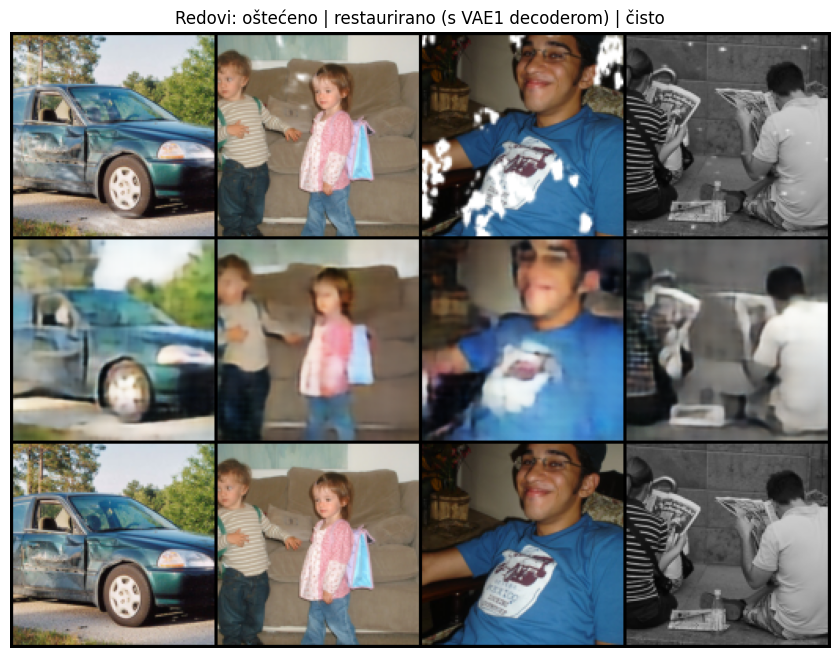

In [25]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open('eval_results_fixed/comparison_grid_synthetic.png')
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis('off')
plt.title('Redovi: oštećeno | restaurirano (s VAE1 decoderom) | čisto')
plt.show()

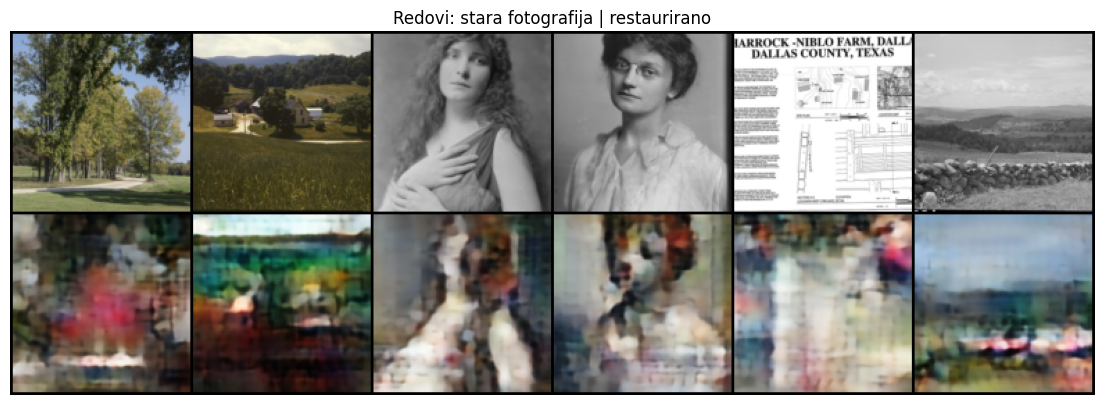

In [26]:
img = Image.open('eval_results_fixed/comparison_grid_real.png')
plt.figure(figsize=(14, 5))
plt.imshow(img)
plt.axis('off')
plt.title('Redovi: stara fotografija | restaurirano')
plt.show()

In [27]:
import pandas as pd
df = pd.read_csv('eval_results_fixed/translation_net_metrics.csv')
print(df.describe())
df

       sample_index  damaged_psnr  damaged_ssim  damaged_lpips  restored_psnr  \
count     30.000000     30.000000     30.000000      30.000000      30.000000   
mean      14.500000     24.295379      0.883359       0.101929      20.367197   
std        8.803408      6.688432      0.089814       0.086036       2.262605   
min        0.000000     13.655154      0.669209       0.014129      15.812572   
25%        7.250000     19.021222      0.835510       0.035478      18.584495   
50%       14.500000     24.295666      0.898996       0.072264      20.510796   
75%       21.750000     29.812118      0.954371       0.159384      22.298507   
max       29.000000     41.296680      0.991584       0.337071      23.863299   

       restored_ssim  restored_lpips  
count      30.000000       30.000000  
mean        0.698271        0.294714  
std         0.073098        0.059512  
min         0.483326        0.188732  
25%         0.660724        0.261288  
50%         0.697159        0.283972

,sample_index,damaged_psnr,damaged_ssim,damaged_lpips,restored_psnr,restored_ssim,restored_lpips
0,0,23.851593,0.939384,0.021538,19.747809,0.681357,0.297431
1,1,31.702108,0.971479,0.030088,22.357067,0.781667,0.224493
2,2,13.655154,0.774296,0.252784,17.083163,0.658749,0.264241
3,3,33.023371,0.959921,0.035287,19.617698,0.734771,0.363693
4,4,24.807031,0.938197,0.040179,21.899302,0.699142,0.246169
5,5,30.372116,0.973475,0.020230,16.743019,0.747652,0.312532
6,6,17.763888,0.863366,0.117828,19.126492,0.611192,0.364534
7,7,29.038968,0.954688,0.049133,17.811626,0.717298,0.279550
8,8,18.320654,0.669209,0.238585,18.491018,0.720582,0.226440
9,9,30.069835,0.978714,0.018560,21.420315,0.625167,0.394368


In [28]:
import shutil

for folder in ['/kaggle/working/voc_data']:
    if os.path.isdir(folder):
        shutil.rmtree(folder)
        print(f'Deleted: {folder}')
    else:
        print(f'Not found (already clean): {folder}')

Not found (already clean): /kaggle/working/voc_data
